# 01 - PA-3: a evasao depende do porte do municipio?

**Story:** US-06 - **Pergunta analitica 3 (PA-3):** a taxa de evasao - o % das
internacoes de moradores de um municipio que aconteceram **fora** dele - depende do
**porte** (tamanho populacional) do municipio?

**Hipotese a testar:** cidades pequenas evadem quase tudo (nao tem hospital que de conta),
cidades grandes retem seus moradores, e os polos (Joao Pessoa e Campina Grande) tem
**saldo positivo** - recebem muito mais gente de fora do que mandam para fora.

**Por que isso importa para a Secretaria de Saude:** se a evasao for um problema
**estrutural do pequeno porte**, a politica publica correta nao e "cada municipio resolve
o seu", e sim pactuar regionalmente quem atende quem. Se a evasao fosse aleatoria (grandes
e pequenos evadindo igual), a explicacao seria outra - ma gestao pontual, por exemplo.

**Entradas (100% offline, nada e baixado aqui):**
- `data/processed/matriz_od_municipal_mensal.parquet` - matriz origem->destino da US-04
  (258.125 internacoes de 2025).
- `data/raw/populacao_ibge_municipios.csv` - estimativa populacional do IBGE, congelada
  no repo por `src/baixar_populacao_ibge.py` (decisao D-3 do backlog).
- `data/raw/municipios_ibge.csv` - tabela de municipios da US-01, usada aqui como
  **de-para** entre o codigo de 7 digitos do IBGE e o de 6 digitos do SIH.

**Saidas:**
- `outputs/tables/pa3_evasao_por_porte.csv`
- `outputs/tables/pa3_saldo_municipios.csv`
- `outputs/figures/pa3_evasao_x_porte.png`

## 1. Carregando as tres entradas

Tres arquivos, tres papeis:

1. **A matriz O-D** diz, para cada par (municipio onde a pessoa mora -> municipio onde ela
   se internou -> mes), quantas internacoes aconteceram. A coluna `evasao_municipal` ja
   vem marcada como `True` quando residencia != internacao.
2. **A populacao do IBGE** da o porte de cada municipio.
3. **A tabela de municipios** existe porque os dois arquivos acima falam "linguas"
   diferentes de codigo: o IBGE usa 7 digitos (2507507 = Joao Pessoa), o SIH usa so os
   6 primeiros, sem o digito verificador (250750). A tabela da US-01 ja traz as duas
   colunas lado a lado (`codigo_ibge7` e `codigo_ibge6`), entao **reaproveitamos** esse
   de-para em vez de reinventar a regra aqui.

Detalhe tecnico: lemos os codigos como **texto** (`dtype=str`), nunca como numero. Codigo
de municipio tem zeros a esquerda em alguns estados, e ler como numero os destruiria.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Caminhos relativos a raiz do projeto (mesmo padrao dos notebooks anteriores)
if Path.cwd().name == "notebooks":
    os.chdir("..")

matriz = pd.read_parquet("data/processed/matriz_od_municipal_mensal.parquet")
populacao = pd.read_csv("data/raw/populacao_ibge_municipios.csv", dtype={"cod_ibge": str})
municipios = pd.read_csv("data/raw/municipios_ibge.csv", dtype=str)

TOTAL_BASE = int(matriz["internacoes"].sum())
ANO_POP = int(populacao["ano_referencia"].iloc[0])

print(f"Matriz O-D: {len(matriz):,} linhas, {TOTAL_BASE:,} internacoes".replace(",", "."))
print(f"Populacao IBGE: {len(populacao):,} municipios, ano de referencia {ANO_POP}".replace(",", "."))
print(f"Tabela de municipios (de-para 7<->6 digitos): {len(municipios):,} linhas".replace(",", "."))

assert TOTAL_BASE == 258125, "A matriz O-D nao tem o total esperado de internacoes!"
print("OK - a matriz de entrada e a mesma validada na US-04 (258.125 internacoes).")

Matriz O-D: 15.054 linhas. 258.125 internacoes
Populacao IBGE: 5.571 municipios. ano de referencia 2025
Tabela de municipios (de-para 7<->6 digitos): 5.571 linhas
OK - a matriz de entrada e a mesma validada na US-04 (258.125 internacoes).


## 2. Universo da analise: so residentes da Paraiba

**Declaracao de metodo (importante).** A base tem internacoes de pessoas que moram em
outros estados e vieram se internar na PB (turistas, fronteiricos, busca de tratamento).
Elas sao uteis para medir *quem recebe*, mas **nao** para medir *taxa de evasao*: dizer
que "99% das internacoes de um morador de Recife aconteceram fora do municipio dele"
e verdade e e irrelevante - a rede de Recife nao esta nesta base.

Por isso, **a taxa de evasao e calculada apenas para `uf_res == 'PB'`**. As internacoes de
nao-residentes continuam contando na secao do saldo (secao 6), onde o que interessa e
justamente quem vem de fora.

**Limitacao declarada (a mesma da US-04):** esta base so enxerga hospitais da PB. Um
paraibano internado em Pernambuco nao aparece aqui - logo, as taxas abaixo sao um **piso**
da evasao real. A dimensao interestadual e assunto da US-08 (PA-5).

In [2]:
residentes_pb = matriz[matriz["uf_res"] == "PB"]

int_pb = int(residentes_pb["internacoes"].sum())
int_fora_pb = TOTAL_BASE - int_pb
print(f"Internacoes de residentes da PB:   {int_pb:,}".replace(",", "."))
print(f"Internacoes de residentes de fora: {int_fora_pb:,} ({100*int_fora_pb/TOTAL_BASE:.1f}% do total)".replace(",", "."))

# Sanity check contra o numero de referencia do projeto (US-04): 50,5% de evasao no ano.
taxa_geral = 100 * matriz.loc[matriz["evasao_municipal"], "internacoes"].sum() / TOTAL_BASE
print(f"\nTaxa de evasao municipal do ano (base inteira): {taxa_geral:.1f}%")
assert round(taxa_geral, 1) == 50.5, f"Sanity check falhou: {taxa_geral:.1f}% != 50,5%"
print("OK - sanity check: reproduz os 50,5% do ano estabelecidos na US-04.")

Internacoes de residentes da PB:   256.623
Internacoes de residentes de fora: 1.502 (0.6% do total)

Taxa de evasao municipal do ano (base inteira): 50.5%
OK - sanity check: reproduz os 50,5% do ano estabelecidos na US-04.


## 3. Taxa de evasao por municipio de residencia

Para cada municipio da PB, duas contas:

- **denominador** = todas as internacoes de moradores daquele municipio (dentro e fora);
- **numerador** = as que aconteceram fora dele (`evasao_municipal == True`).

A taxa e `100 x numerador / denominador`. Um municipio com taxa de 100% nao internou
**nenhum** morador dentro de casa no ano inteiro - sinal quase certo de que nao tem
hospital com leito SUS habilitado.

Fazemos as duas contas com um unico `groupby` usando um truque simples: criamos uma coluna
`internacoes_fora` que vale o numero de internacoes quando houve evasao e 0 quando nao
houve. Somando as duas colunas no mesmo agrupamento, saem numerador e denominador juntos -
menos codigo, menos chance de as duas contas divergirem.

In [3]:
base = residentes_pb.copy()
base["internacoes_fora"] = base["internacoes"].where(base["evasao_municipal"], 0)

evasao_mun = (
    base.groupby(["cod_mun_res", "nome_mun_res"], observed=True)
    .agg(
        internacoes_residentes=("internacoes", "sum"),
        internacoes_fora=("internacoes_fora", "sum"),
    )
    .reset_index()
)
evasao_mun["taxa_evasao_pct"] = (
    100 * evasao_mun["internacoes_fora"] / evasao_mun["internacoes_residentes"]
)

# Validacao (a): nenhuma internacao de residente da PB se perdeu no agrupamento.
soma = int(evasao_mun["internacoes_residentes"].sum())
print(f"Soma do agrupamento por municipio: {soma:,}".replace(",", "."))
assert soma == int_pb, "O agrupamento por municipio perdeu/criou internacoes!"

# Validacao (b): taxas dentro do intervalo possivel.
assert evasao_mun["taxa_evasao_pct"].between(0, 100).all(), "Taxa fora do intervalo 0-100%!"

print(f"Municipios de residencia na PB: {evasao_mun['cod_mun_res'].nunique()}")
print(f"Taxa minima: {evasao_mun['taxa_evasao_pct'].min():.1f}% | maxima: {evasao_mun['taxa_evasao_pct'].max():.1f}%")
print("OK - validacoes (a) soma preservada e (b) taxas entre 0 e 100%.")

Soma do agrupamento por municipio: 256.623
Municipios de residencia na PB: 223
Taxa minima: 1.8% | maxima: 100.0%
OK - validacoes (a) soma preservada e (b) taxas entre 0 e 100%.


## 4. Juntando a populacao (o join dos 6 vs 7 digitos)

Aqui esta a unica armadilha tecnica da story. A matriz O-D traz `cod_mun_res` com **6
digitos** (padrao SIH). O CSV do IBGE traz `cod_ibge` com **7 digitos**. Juntar direto
daria 100% de orfaos.

A solucao ja existe no repo: `data/raw/municipios_ibge.csv` (US-01) tem as duas colunas.
Entao o caminho e: **populacao (7 digitos) -> tabela de municipios -> codigo de 6 digitos ->
matriz O-D**. O 7o digito e apenas um verificador (como o digito final do CPF), e o
prefixo de 6 digitos e unico no pais inteiro - o `src/baixar_municipios_ibge.py` ja
verifica isso com um `assert`, entao o join e seguro.

**Validacao exigida pela story:** cobertura do join = 100%, orfaos = 0. Se algum municipio
da PB ficasse sem populacao, a analise de porte estaria incompleta e o `assert` derruba o
notebook.

In [4]:
# Ponte: codigo de 7 digitos (IBGE) -> codigo de 6 digitos (SIH)
pop_pb = populacao[populacao["uf"] == "PB"].merge(
    municipios[["codigo_ibge7", "codigo_ibge6"]],
    left_on="cod_ibge",
    right_on="codigo_ibge7",
    how="left",
)
assert pop_pb["codigo_ibge6"].notna().all(), "Municipio do IBGE sem codigo de 6 digitos!"
assert len(pop_pb) == 223, f"Esperados 223 municipios da PB, vieram {len(pop_pb)}"
print(f"Municipios da PB com populacao (ano {ANO_POP}): {len(pop_pb)}")

dados = evasao_mun.merge(
    pop_pb[["codigo_ibge6", "populacao"]],
    left_on="cod_mun_res",
    right_on="codigo_ibge6",
    how="left",
).drop(columns="codigo_ibge6")

# Validacao (c): cobertura do join populacao x municipios da matriz.
orfaos = dados[dados["populacao"].isna()]
print(f"Municipios da matriz sem populacao atribuida (orfaos): {len(orfaos)}")
assert len(orfaos) == 0, f"Orfaos no join de populacao: {orfaos['nome_mun_res'].tolist()}"

# Validacao (d): a soma de internacoes sobreviveu ao join (joins podem duplicar linhas).
assert int(dados["internacoes_residentes"].sum()) == int_pb, "O join com a populacao alterou os totais!"
print("OK - validacoes (c) zero orfaos e (d) soma de internacoes preservada apos o join.")

dados["populacao"] = dados["populacao"].astype(int)
dados.sort_values("populacao", ascending=False).head(8)

Municipios da PB com populacao (ano 2025): 223
Municipios da matriz sem populacao atribuida (orfaos): 0
OK - validacoes (c) zero orfaos e (d) soma de internacoes preservada apos o join.


,cod_mun_res,nome_mun_res,internacoes_residentes,internacoes_fora,taxa_evasao_pct,populacao
95,250750,João Pessoa,51512,1863,3.616633,897633
51,250400,Campina Grande,32821,584,1.779349,443911
174,251370,Santa Rita,9997,5788,57.897369,160852
135,251080,Patos,6724,1205,17.920880,108104
25,250180,Bayeux,4733,4718,99.683076,83862
41,250320,Cabedelo,4031,2317,57.479534,70734
210,251620,Sousa,4511,947,20.993128,70066
47,250370,Cajazeiras,5080,847,16.673228,66585


## 5. Faixas de porte - qual convencao usamos e por que

Comparar 223 municipios um a um nao responde nada; e preciso agrupa-los em **faixas de
porte**. A escolha das faixas nao pode ser arbitraria (mudar os cortes muda o resultado),
entao adotamos uma convencao **publica e ja usada no setor publico brasileiro**:

> **Classificacao de porte populacional da PNAS/SUAS** (Politica Nacional de Assistencia
> Social - a regua padrao para classificar municipios brasileiros por porte):
> Pequeno Porte I (ate 20.000 hab.), Pequeno Porte II (20.001 a 50.000),
> Medio Porte (50.001 a 100.000), Grande Porte (100.001 a 900.000) e Metropole
> (acima de 900.000).

**Um ajuste, declarado:** a Paraiba e um estado de municipios muito pequenos - 140 dos 223
tem menos de 10 mil habitantes. Jogar todos eles na mesma caixa "Pequeno Porte I"
esconderia justamente o extremo que a hipotese quer testar. Por isso **quebramos a faixa
Pequeno Porte I em duas** (ate 10 mil / 10 a 20 mil) e mantivemos as demais como na PNAS.
Nenhum municipio da PB chega a 900 mil habitantes (Joao Pessoa, o maior, tem 897.633), entao
"Grande Porte" e "Metropole" viram uma faixa so: acima de 100 mil.

Faixas finais: **ate 10 mil - 10 a 20 mil - 20 a 50 mil - 50 a 100 mil - acima de 100 mil.**

In [5]:
LIMITES = [0, 10_000, 20_000, 50_000, 100_000, np.inf]
ROTULOS = ["Ate 10 mil", "10 a 20 mil", "20 a 50 mil", "50 a 100 mil", "Acima de 100 mil"]

dados["porte"] = pd.cut(dados["populacao"], bins=LIMITES, labels=ROTULOS, right=True)
assert dados["porte"].notna().all(), "Municipio sem faixa de porte atribuida!"

print("Quantos municipios da PB em cada faixa:")
print(dados["porte"].value_counts().sort_index().to_string())

Quantos municipios da PB em cada faixa:
porte
Ate 10 mil          140
10 a 20 mil          50
20 a 50 mil          22
50 a 100 mil          7
Acima de 100 mil      4


### A tabela da PA-3

Para cada faixa calculamos **duas** taxas, que respondem perguntas diferentes:

- **`taxa_evasao_pct` (agregada)** - soma as internacoes de todos os municipios da faixa e
  divide. E a taxa "do ponto de vista do paciente": de cada 100 internacoes de moradores de
  cidades desse porte, quantas aconteceram fora. **E a taxa principal.**
- **`taxa_mediana_pct`** - a mediana das taxas municipais da faixa. E a taxa "do ponto de
  vista do municipio tipico". Serve de controle: se as duas contam a mesma historia, o
  resultado nao e efeito de um municipio gigante puxando a media.

In [6]:
por_porte = (
    dados.groupby("porte", observed=True)
    .agg(
        municipios=("cod_mun_res", "size"),
        populacao_total=("populacao", "sum"),
        internacoes_residentes=("internacoes_residentes", "sum"),
        internacoes_fora=("internacoes_fora", "sum"),
        taxa_mediana_pct=("taxa_evasao_pct", "median"),
    )
    .reset_index()
)
por_porte["taxa_evasao_pct"] = (
    100 * por_porte["internacoes_fora"] / por_porte["internacoes_residentes"]
).round(1)
por_porte["taxa_mediana_pct"] = por_porte["taxa_mediana_pct"].round(1)
por_porte = por_porte[
    [
        "porte",
        "municipios",
        "populacao_total",
        "internacoes_residentes",
        "internacoes_fora",
        "taxa_evasao_pct",
        "taxa_mediana_pct",
    ]
]

# Validacao (e): as faixas somadas reconstroem o universo (223 municipios, todas as internacoes).
assert int(por_porte["municipios"].sum()) == 223, "As faixas nao cobrem os 223 municipios!"
assert int(por_porte["internacoes_residentes"].sum()) == int_pb, "As faixas perderam internacoes!"
print("OK - validacao (e): as 5 faixas somam 223 municipios e todas as internacoes de residentes da PB.")

por_porte

OK - validacao (e): as 5 faixas somam 223 municipios e todas as internacoes de residentes da PB.


,porte,municipios,populacao_total,internacoes_residentes,internacoes_fora,taxa_evasao_pct,taxa_mediana_pct
0,Ate 10 mil,140,744292,44557,43723,98.1,100.0
1,10 a 20 mil,50,743921,44928,36108,80.4,98.4
2,20 a 50 mil,22,610296,38409,24934,64.9,76.3
3,50 a 100 mil,7,455459,27675,14672,53.0,57.5
4,Acima de 100 mil,4,1610500,101054,9440,9.3,10.8


In [7]:
# Quantas das 140 cidades ate 10 mil habitantes tem taxa de evasao de EXATAMENTE 100%?
# (o reviewer independente da US-06 apontou que a frase original - "mais da metade" -
# subestimava o achado; calculamos aqui o numero exato em vez de escrever a mao.)
faixa_menor = dados[dados["porte"] == "Ate 10 mil"]
n_faixa_menor = len(faixa_menor)
n_taxa_100 = int((faixa_menor["taxa_evasao_pct"] == 100).sum())
pct_taxa_100 = 100 * n_taxa_100 / n_faixa_menor

print(f"Cidades ate 10 mil habitantes: {n_faixa_menor}")
print(
    f"Dessas, com taxa de evasao de exatamente 100% "
    f"(nenhum morador internado dentro de casa no ano): "
    f"{n_taxa_100} ({pct_taxa_100:.0f}%)"
)
assert n_taxa_100 <= n_faixa_menor, "Contagem de 100% nao pode exceder o total da faixa!"

Cidades ate 10 mil habitantes: 140
Dessas, com taxa de evasao de exatamente 100% (nenhum morador internado dentro de casa no ano): 133 (95%)


**Leitura direta da tabela:** a taxa de evasao cai **monotonicamente** - sem uma unica
inversao - conforme o porte sobe. De ~98% nas cidades de ate 10 mil habitantes ate ~9% nas
acima de 100 mil. E a mediana conta a mesma historia da agregada, o que descarta a hipotese
de que o efeito venha de um ou dois municipios grandes distorcendo a conta.

Vale registrar o contraste extremo: no grupo de ate 10 mil habitantes, a **mediana e 100%** -
**133 das 140 cidades dessa faixa (95%) nao internaram nenhum morador dentro de casa no ano
inteiro** (numero calculado na celula acima, nao estimado).

## 6. Saldo migratorio assistencial: quem importa e quem exporta pacientes

Taxa de evasao so olha para o lado de quem **sai**. A outra metade da historia e quem
**recebe**. Definimos, para cada municipio:

- **recebidos de fora** = internacoes realizadas ali de pessoas que moram em outro municipio
  (qualquer origem, inclusive de outros estados - e exatamente o fluxo que os polos
  absorvem);
- **enviados para fora** = internacoes de moradores dali realizadas em outro municipio;
- **saldo = recebidos - enviados.**

Saldo **positivo** = municipio **importador** de pacientes: e um polo, sua rede atende alem
da propria populacao. Saldo **negativo** = **exportador**: depende da rede de fora.

*Nota:* todos os hospitais desta base ficam na PB, entao todo destino e um municipio
paraibano; a origem, nao - dai a assimetria proposital entre as duas contas.

In [8]:
evadidas = matriz[matriz["evasao_municipal"]]

recebidos = (
    evadidas.groupby("cod_mun_int", observed=True)["internacoes"].sum().rename("recebidos_de_fora")
)
enviados = (
    evadidas[evadidas["uf_res"] == "PB"]
    .groupby("cod_mun_res", observed=True)["internacoes"]
    .sum()
    .rename("enviados_para_fora")
)

# Dicionario codigo -> nome cobrindo municipios que aparecem so como origem ou so como destino
nomes = pd.concat(
    [
        matriz[["cod_mun_res", "nome_mun_res"]].rename(
            columns={"cod_mun_res": "cod", "nome_mun_res": "nome"}
        ),
        matriz[["cod_mun_int", "nome_mun_int"]].rename(
            columns={"cod_mun_int": "cod", "nome_mun_int": "nome"}
        ),
    ]
).drop_duplicates("cod").set_index("cod")["nome"]

saldo = (
    pd.concat([recebidos, enviados], axis=1)
    .fillna(0)
    .astype(int)
    .rename_axis("cod_municipio")
    .reset_index()
)
saldo["nome_municipio"] = saldo["cod_municipio"].map(nomes)
saldo["saldo"] = saldo["recebidos_de_fora"] - saldo["enviados_para_fora"]
# So municipios da PB (codigo de UF 25) - os de fora aparecem apenas como origem.
saldo = saldo[saldo["cod_municipio"].str.startswith("25")]
saldo = saldo.merge(
    dados[["cod_mun_res", "populacao", "porte", "taxa_evasao_pct"]],
    left_on="cod_municipio",
    right_on="cod_mun_res",
    how="left",
).drop(columns="cod_mun_res")
saldo = saldo[
    [
        "cod_municipio",
        "nome_municipio",
        "populacao",
        "porte",
        "recebidos_de_fora",
        "enviados_para_fora",
        "saldo",
        "taxa_evasao_pct",
    ]
].sort_values("saldo", ascending=False).reset_index(drop=True)

# Validacao (f): o total de internacoes "fora do municipio" fecha pelos dois lados.
total_evadidas = int(evadidas["internacoes"].sum())
assert int(saldo["recebidos_de_fora"].sum()) == total_evadidas, "Recebidos nao fecham com o total de evasoes!"
print(f"Internacoes fora do municipio de residencia (ano): {total_evadidas:,}".replace(",", "."))
print("OK - validacao (f): a soma dos recebidos por destino = total de internacoes com evasao.")

print("\nOs 5 maiores importadores de pacientes:")
saldo.head(5)

Internacoes fora do municipio de residencia (ano): 130.379
OK - validacao (f): a soma dos recebidos por destino = total de internacoes com evasao.

Os 5 maiores importadores de pacientes:


,cod_municipio,nome_municipio,populacao,porte,recebidos_de_fora,enviados_para_fora,saldo,taxa_evasao_pct
0,250750,João Pessoa,897633,Acima de 100 mil,43624,1863,41761,3.616633
1,250400,Campina Grande,443911,Acima de 100 mil,32817,584,32233,1.779349
2,251080,Patos,108104,Acima de 100 mil,11147,1205,9942,17.920880
3,250370,Cajazeiras,66585,50 a 100 mil,4573,847,3726,16.673228
4,250890,Mamanguape,46966,20 a 50 mil,4308,1556,2752,47.439024


### Sanity check dos polos

O contexto conhecido do projeto diz: **Joao Pessoa recebe 43.624 nao-residentes e Campina
Grande, 32.817**. Se nossa conta reproduzir esses dois numeros exatamente, a definicao de
"recebidos de fora" esta certa. Os `assert` abaixo travam o notebook se nao bater.

In [9]:
def olhar(nome):
    linha = saldo[saldo["nome_municipio"] == nome].iloc[0]
    print(
        f"{nome}: recebe {linha['recebidos_de_fora']:,} de fora | "
        f"manda {linha['enviados_para_fora']:,} para fora | "
        f"saldo {linha['saldo']:+,} | taxa de evasao {linha['taxa_evasao_pct']:.1f}%".replace(",", ".")
    )
    return linha


jp = olhar("Joao Pessoa") if "Joao Pessoa" in set(saldo["nome_municipio"]) else olhar("João Pessoa")
cg = olhar("Campina Grande")

assert int(jp["recebidos_de_fora"]) == 43624, "Joao Pessoa divergiu do numero de referencia!"
assert int(cg["recebidos_de_fora"]) == 32817, "Campina Grande divergiu do numero de referencia!"
print("\nOK - sanity check dos polos: 43.624 (JP) e 32.817 (CG) reproduzidos exatamente.")

# Checagem pedida no criterio de aceite: polos com evasao < 10% E importadores liquidos.
assert jp["taxa_evasao_pct"] < 10 and cg["taxa_evasao_pct"] < 10, "Polo com evasao >= 10%!"
assert jp["saldo"] > 0 and cg["saldo"] > 0, "Polo nao e importador liquido!"
print("OK - os dois polos tem evasao abaixo de 10% e saldo positivo (importadores liquidos).")

print("\nOs 5 maiores exportadores de pacientes:")
saldo.tail(5).sort_values("saldo")

João Pessoa: recebe 43.624 de fora | manda 1.863 para fora | saldo +41.761 | taxa de evasao 3.6%
Campina Grande: recebe 32.817 de fora | manda 584 para fora | saldo +32.233 | taxa de evasao 1.8%

OK - sanity check dos polos: 43.624 (JP) e 32.817 (CG) reproduzidos exatamente.
OK - os dois polos tem evasao abaixo de 10% e saldo positivo (importadores liquidos).

Os 5 maiores exportadores de pacientes:


,cod_municipio,nome_municipio,populacao,porte,recebidos_de_fora,enviados_para_fora,saldo,taxa_evasao_pct
222,250180,Bayeux,83862,50 a 100 mil,8,4718,-4710,99.683076
221,251530,Sapé,53457,50 a 100 mil,61,2372,-2311,80.135135
220,250320,Cabedelo,70734,50 a 100 mil,120,2317,-2197,57.479534
219,250460,Conde,30007,20 a 50 mil,0,1833,-1833,100.000000
218,251120,Pedras de Fogo,31356,20 a 50 mil,22,1591,-1569,74.659784


In [10]:
# Que fatia de TODO o deslocamento hospitalar do estado (as 130.379 internacoes evadidas)
# os dois polos absorvem sozinhos? Calculado, nao estimado - substitui a frase vaga
# "mais da metade" do veredito original (apontado no review independente da US-06).
recebidos_polos = int(jp["recebidos_de_fora"] + cg["recebidos_de_fora"])
pct_polos_do_total_evadido = 100 * recebidos_polos / total_evadidas

print(
    f"Joao Pessoa + Campina Grande recebem juntas {recebidos_polos:,} internacoes evadidas "
    f"de outros municipios,".replace(",", ".")
)
print(
    f"o que representa {pct_polos_do_total_evadido:.1f}% do total de {total_evadidas:,} "
    f"internacoes evadidas no estado no ano.".replace(",", ".")
)
assert pct_polos_do_total_evadido > 50, "A checagem de 'mais da metade' nao se confirmou!"

Joao Pessoa + Campina Grande recebem juntas 76.441 internacoes evadidas de outros municipios.
o que representa 58.6% do total de 130.379 internacoes evadidas no estado no ano.


## 7. A excecao que confirma a regra: as cidades conurbadas com os polos

Antes do grafico, um caso que parece contrariar a hipotese e nao contraria: **Bayeux
(83.862 hab.) evade 99,7%** e **Santa Rita (160.852 hab.) evade 57,9%** - taxas de cidade
pequena em cidades medias/grandes.

As duas sao **coladas em Joao Pessoa** (regiao metropolitana, conurbadas: quem mora la
atravessa uma avenida e esta na capital). Ou seja: parte do que a estatistica chama de
"evasao" nessas cidades e **geografia administrativa**, nao falta de acesso. O paciente
nao percorre 200 km - ele cruza a divisa do bairro.

Isso e uma **limitacao real da metrica** e precisa constar do veredito: a fronteira
municipal e uma linha no mapa, nao uma medida de distancia percorrida. Ela nao invalida o
padrao geral (que e fortissimo), mas explica os pontos fora da curva.

In [11]:
grandes = dados[dados["populacao"] > 50_000].sort_values("populacao", ascending=False)
grandes[["nome_mun_res", "populacao", "internacoes_residentes", "internacoes_fora", "taxa_evasao_pct"]].round(1)

,nome_mun_res,populacao,internacoes_residentes,internacoes_fora,taxa_evasao_pct
95,João Pessoa,897633,51512,1863,3.6
51,Campina Grande,443911,32821,584,1.8
174,Santa Rita,160852,9997,5788,57.9
135,Patos,108104,6724,1205,17.9
25,Bayeux,83862,4733,4718,99.7
41,Cabedelo,70734,4031,2317,57.5
210,Sousa,70066,4511,947,21.0
47,Cajazeiras,66585,5080,847,16.7
83,Guarabira,60057,3540,1677,47.4
198,Sapé,53457,2960,2372,80.1


## 8. A visualizacao (titulo-afirmacao)

Regra do projeto (RNF-04): o titulo do grafico **afirma o achado**, nao descreve o eixo.
"Evasao por porte" nao diz nada; "Quanto menor a cidade, mais seus moradores se internam
fora" ja entrega a conclusao a quem so olhou a figura.

Sao dois paineis complementares:
- **esquerda** - as barras da tabela da secao 5: a queda da taxa faixa a faixa;
- **direita** - cada municipio da PB como um ponto (populacao no eixo horizontal, em escala
  logaritmica porque Joao Pessoa tem 500x a populacao do menor municipio; taxa de evasao no
  vertical). Mostra que a queda e continua, nao um artefato dos cortes que escolhemos.

Sem jargao nos rotulos: "moradores internados fora da propria cidade (%)".

Figura salva em outputs\figures\pa3_evasao_x_porte.png (dpi=200)


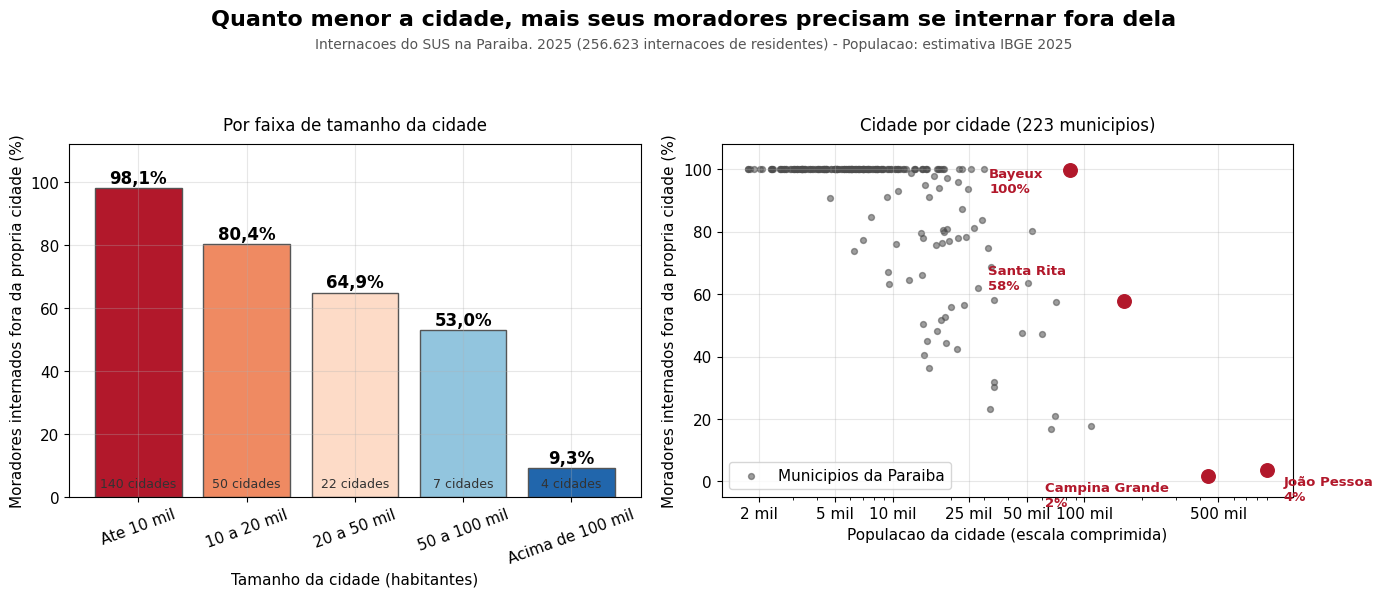

In [12]:
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Painel 1: barras por faixa de porte ---
cores = ["#b2182b", "#ef8a62", "#fddbc7", "#92c5de", "#2166ac"]
barras = ax1.bar(por_porte["porte"].astype(str), por_porte["taxa_evasao_pct"], color=cores, edgecolor="#555555")
for barra, valor, n in zip(barras, por_porte["taxa_evasao_pct"], por_porte["municipios"]):
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1.5,
        f"{valor:.1f}%".replace(".", ","),
        ha="center",
        fontweight="bold",
        fontsize=12,
    )
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        3,
        f"{n} cidades",
        ha="center",
        fontsize=9,
        color="#333333",
    )
ax1.set_ylim(0, 112)
ax1.set_ylabel("Moradores internados fora da propria cidade (%)")
ax1.set_xlabel("Tamanho da cidade (habitantes)")
ax1.set_title("Por faixa de tamanho da cidade", fontsize=12, pad=10)
ax1.tick_params(axis="x", rotation=20)

# --- Painel 2: cada municipio como um ponto ---
ax2.scatter(
    dados["populacao"],
    dados["taxa_evasao_pct"],
    s=18,
    alpha=0.55,
    color="#4d4d4d",
    label="Municipios da Paraiba",
)
destaques = {
    "Joao Pessoa": (12, -22),
    "Campina Grande": (-118, -22),
    "Bayeux": (-58, -16),
    "Santa Rita": (-98, 8),
}
for nome, deslocamento in destaques.items():
    alvo = dados[dados["nome_mun_res"].str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii") == nome]
    p = alvo.iloc[0]
    ax2.scatter(p["populacao"], p["taxa_evasao_pct"], s=95, color="#b2182b", zorder=5)
    ax2.annotate(
        f"{p['nome_mun_res']}\n{p['taxa_evasao_pct']:.0f}%",
        (p["populacao"], p["taxa_evasao_pct"]),
        textcoords="offset points",
        xytext=deslocamento,
        fontsize=9.5,
        color="#b2182b",
        fontweight="bold",
    )
ax2.set_xscale("log")
ax2.set_xticks([2_000, 5_000, 10_000, 25_000, 50_000, 100_000, 500_000])
ax2.set_xticklabels(["2 mil", "5 mil", "10 mil", "25 mil", "50 mil", "100 mil", "500 mil"])
ax2.set_ylim(-5, 108)
ax2.set_xlabel("Populacao da cidade (escala comprimida)")
ax2.set_ylabel("Moradores internados fora da propria cidade (%)")
ax2.set_title("Cidade por cidade (223 municipios)", fontsize=12, pad=10)
ax2.legend(loc="lower left", frameon=True)

fig.suptitle(
    "Quanto menor a cidade, mais seus moradores precisam se internar fora dela",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)
fig.text(
    0.5,
    0.925,
    f"Internacoes do SUS na Paraiba, 2025 ({int_pb:,} internacoes de residentes)".replace(",", ".")
    + f" - Populacao: estimativa IBGE {ANO_POP}",
    ha="center",
    fontsize=10,
    color="#555555",
)
fig.tight_layout(rect=[0, 0, 1, 0.90])

destino_fig = Path("outputs/figures/pa3_evasao_x_porte.png")
destino_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(destino_fig, dpi=200, bbox_inches="tight")
print(f"Figura salva em {destino_fig} (dpi=200)")
plt.show()

## 9. Salvando as tabelas em `outputs/tables/`

Dois CSVs, para que qualquer numero citado na apresentacao seja rastreavel ate um arquivo
versionado (RNF-05 - nenhum numero magico):

| Arquivo | Conteudo |
|---|---|
| `pa3_evasao_por_porte.csv` | as 5 faixas de porte com taxa agregada e mediana |
| `pa3_saldo_municipios.csv` | os 223 municipios com recebidos, enviados, saldo, populacao e taxa |

In [13]:
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
saida_porte = Path("outputs/tables/pa3_evasao_por_porte.csv")
saida_saldo = Path("outputs/tables/pa3_saldo_municipios.csv")

por_porte.to_csv(saida_porte, index=False, encoding="utf-8")
saldo.to_csv(saida_saldo, index=False, encoding="utf-8")

for p in (saida_porte, saida_saldo):
    print(f"Salvo: {p} ({p.stat().st_size / 1024:,.1f} KB)")

# Conferencia pos-gravacao: relemos e checamos os totais.
rel = pd.read_csv(saida_saldo)
assert len(rel) == 223, f"O CSV de saldo tem {len(rel)} linhas, esperados 223!"
assert int(rel["recebidos_de_fora"].sum()) == total_evadidas, "O CSV relido nao fecha com o total de evasoes!"
print("Conferencia pos-gravacao: 223 municipios e totais preservados - OK.")

Salvo: outputs\tables\pa3_evasao_por_porte.csv (0.3 KB)
Salvo: outputs\tables\pa3_saldo_municipios.csv (12.8 KB)
Conferencia pos-gravacao: 223 municipios e totais preservados - OK.


## 10. Resumo das validacoes (criterios de aceite da US-06)

| Validacao | Resultado |
|---|---|
| Sanity check da base - evasao do ano | 50,5% OK (bate com a US-04) |
| (a) Soma preservada no agrupamento por municipio | 256.623 = 256.623 OK |
| (b) Taxas dentro de 0-100% | OK |
| (c) Cobertura do join populacao x municipios | 223/223 - **orfaos = 0** OK |
| (d) Soma preservada apos o join | OK |
| (e) Faixas de porte cobrem 223 municipios e todas as internacoes | OK |
| (f) Recebidos por destino = total de internacoes com evasao | OK |
| Sanity check dos polos | Joao Pessoa 43.624 - Campina Grande 32.817 OK (exatos) |
| Polos com evasao < 10% e importadores liquidos | JP 3,6% - CG 1,8% - saldos positivos OK |

## 11. Veredito da PA-3

# PA-3 **CONFIRMADA**

**A evasao hospitalar na Paraiba e um problema de porte do municipio, e a relacao e
praticamente perfeita.** Nas 140 cidades paraibanas com ate 10 mil habitantes, **98 de cada
100 internacoes de seus moradores acontecem fora de casa** - e **133 dessas 140 cidades
(95%) nao internaram nenhum** morador dentro do proprio municipio no ano inteiro (numero
calculado na secao 5, nao estimado). Conforme a cidade
cresce, a taxa cai sem uma unica inversao: 80% na faixa de 10 a 20 mil, 65% de 20 a 50 mil,
53% de 50 a 100 mil e apenas **9% nas quatro cidades acima de 100 mil habitantes**. Do outro
lado do fluxo estao os polos: Joao Pessoa interna fora apenas 3,6% de seus moradores e recebe
**43.624** pacientes de outros municipios (saldo de +41.761); Campina Grande interna fora 1,8%
e recebe **32.817** (saldo de +32.233). Juntas, as duas cidades absorvem **58,6%** de
todo o deslocamento hospitalar do estado (76.441 das 130.379 internacoes evadidas no ano,
calculado na secao 6). A leitura para a gestao e direta: **a evasao nao e
falha de gestao de cada prefeitura pequena - e o desenho da rede.** Municipios de ate 20 mil
habitantes nao sustentam hospital com leito SUS de porte, e por isso o instrumento correto
nao e "cada um resolve o seu", e sim a pactuacao regional (PPI) que reconheca formalmente -
e financie - o papel de polo de Joao Pessoa, Campina Grande, Patos e Cajazeiras.

**Limitacoes declaradas (o que este numero nao diz):**

1. **Fronteira municipal nao e distancia percorrida.** Bayeux (99,7% de evasao) e Santa Rita
   (57,9%) sao grandes e ainda assim "evadem" muito, porque sao conurbadas com Joao Pessoa -
   o morador atravessa uma avenida, nao 200 km. A metrica conta troca de municipio, nao
   esforco de deslocamento. Uma versao futura poderia ponderar por distancia real.
2. **A base so enxerga hospitais da Paraiba.** Um paraibano internado em Pernambuco ou no Rio
   Grande do Norte nao aparece aqui. As taxas sao, portanto, um **piso** da evasao real - a
   dimensao interestadual e medida separadamente na PA-5 (US-08).
3. **A unidade de contagem e a AIH, nao a pessoa.** Quem se internou tres vezes conta tres
   vezes; reinternacoes e transferencias podem inflar municipios com pacientes cronicos.
4. **Correlacao nao e causalidade.** O porte explica o padrao, mas a causa direta e a
   ausencia de leito SUS habilitado no municipio - que a base do SIH nao mede diretamente.
   Cruzar com o CNES (cadastro de estabelecimentos) fecharia esse argumento.
5. **Anos de referencia.** As internacoes sao de 2025 e a populacao e a estimativa IBGE de
   2025 - os dois coincidem neste caso, o que elimina qualquer descompasso temporal.